# Predicting Developer Compensation

**Capstone – Main notebook**

- **Track:** Supervised Learning – Regression  
- **Dataset:** Stack Overflow Developer Survey 2025  
- **Target:** `ConvertedCompYearly` (annual compensation in USD)  
- **Goal:** R² ≥ 0.55, RMSE/MAE, SHAP interpretability; beat median baseline.

---

## 1. Setup and load data

**In Colab:** Click the **Files** icon (📁) in the left sidebar → **Upload to session storage** → choose your CSV. Then run the cells below.

In [133]:
# Run this cell ONCE if you get ModuleNotFoundError (installs into the notebook's Python).
# Installs: pandas, numpy, matplotlib, seaborn, scikit-learn.
# Then run the "Imports" cell below. If it still fails, use Kernel → Restart, then run both cells again.
%pip install pandas numpy matplotlib seaborn scikit-learn xgboost --quiet

Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\hp\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


In [134]:
# Imports (install first: pip install -r requirements.txt in your env, then restart kernel if needed)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

pd.set_option('display.max_columns', 50)
%matplotlib inline

In [135]:
# Load data (works from project root or from notebooks/; in Colab, upload CSV and use 'survey_results_public.csv')
from pathlib import Path
data_path = Path('../survey_results_public.csv') if Path('../survey_results_public.csv').exists() else Path('survey_results_public.csv')
df = pd.read_csv(data_path, low_memory=False)

df.shape

(49191, 172)

### Proposal & data check (head only)

Check that the dataset has the target and key features from the proposal. We only read a small number of rows here for inspection.

In [136]:
# Key columns from proposal: target + main features
PROPOSAL_KEY_COLS = [
    'ConvertedCompYearly',  # target
    'YearsCode', 'WorkExp', 'Country', 'RemoteWork', 'DevType', 'ICorPM',
    'EdLevel', 'LanguageHaveWorkedWith', 'DatabaseHaveWorkedWith', 'OrgSize', 'AISelect'
]
missing = [c for c in PROPOSAL_KEY_COLS if c not in df.columns]
if missing:
    print('Missing columns:', missing)
else:
    print('All proposal key columns present.')
# Preview with head only (no full-table scan)
df[PROPOSAL_KEY_COLS].head()

All proposal key columns present.


,ConvertedCompYearly,YearsCode,WorkExp,Country,RemoteWork,DevType,ICorPM,EdLevel,LanguageHaveWorkedWith,DatabaseHaveWorkedWith,OrgSize,AISelect
0,61256.0,14.0,8.0,Ukraine,Remote,"Developer, mobile",People manager,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Bash/Shell (all shells);Dart;SQL,Cloud Firestore;PostgreSQL,20 to 99 employees,"Yes, I use AI tools monthly or infrequently"
1,104413.0,10.0,2.0,Netherlands,"Hybrid (some in-person, leans heavy to flexibi...","Developer, back-end",Individual contributor,"Associate degree (A.A., A.S., etc.)",Java,Dynamodb;MongoDB,500 to 999 employees,"Yes, I use AI tools weekly"
2,53061.0,12.0,10.0,Ukraine,NaN,"Developer, front-end",NaN,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Dart;HTML/CSS;JavaScript;TypeScript,MongoDB;MySQL;PostgreSQL,NaN,"Yes, I use AI tools daily"
3,36197.0,5.0,4.0,Ukraine,Remote,"Developer, back-end",Individual contributor,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Java;Kotlin;SQL,NaN,"10,000 or more employees","Yes, I use AI tools weekly"
4,60000.0,22.0,21.0,Ukraine,NaN,Engineering manager,NaN,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",C;C#;C++;Delphi;HTML/CSS;Java;JavaScript;Lua;P...,Elasticsearch;Microsoft SQL Server;MySQL;Oracl...,NaN,"Yes, I use AI tools weekly"


---

## 2. Column strategy & feature engineering

We treat each column by type and role. Decisions are documented so the pipeline is reproducible and defensible in a review.

### 2.1 Data dictionary & cleaning assumptions

| Column | Role | Type | Handling |
|--------|------|------|----------|
| **ConvertedCompYearly** | Target | Numeric | Drop missing; cap at 99th percentile; log-transform for modeling (reduces skew, stabilizes variance). |
| **YearsCode**, **WorkExp** | Experience proxies | Numeric | Already numeric. Impute missing with median (per-cohort or global); no capping (interpretable as-is). |
| **Country** | Geography | Categorical (high cardinality) | Top-N by frequency + "Other"; or map to region/income tier if we want fewer, interpretable levels. |
| **RemoteWork** | Work mode | Ordinal-like | Encode as ordered (e.g. In-person &lt; Hybrid &lt; Remote) or one-hot; missing → mode or "Unknown". |
| **DevType** | Role | Multi-select text | Split on `;`, take primary (first) or multi-hot for top-K role labels. |
| **ICorPM** | Seniority signal | Binary-like | Individual contributor vs People manager; missing → mode. |
| **EdLevel** | Education | Ordinal | Map to ordered levels (e.g. 1–5); missing → mode or "Prefer not to say". |
| **LanguageHaveWorkedWith**, **DatabaseHaveWorkedWith** | Tech stack | Multi-select (`;`-sep) | Multi-hot for top-K technologies; controls dimensionality and avoids rare-level noise. |
| **OrgSize** | Employer size | Ordinal | Map to ordered numeric (e.g. 1–7); missing → mode. |
| **AISelect** | AI adoption | Ordinal/categorical | Encode by usage intensity (e.g. daily &gt; weekly &gt; monthly &gt; never); 2025 differentiator. |

**Principles:** One consistent train/test split; no leakage from target into features; all choices recorded for reproducibility.

In [137]:
# Configuration: single source of truth for cleaning and encoding
RANDOM_STATE = 42
TARGET = "ConvertedCompYearly"
PERCENTILE_CAP = 99
TOP_COUNTRIES = 15
TOP_LANGUAGES = 20
TOP_DATABASES = 15
TOP_DEV_TYPES = 12

# Ordinal mappings (order reflects increasing level / intensity where applicable)
# Normalize apostrophes so CSV variants (e.g. \u2019) match
def _norm(s):
    return s.replace("\u2019", "'").replace("'", "'").strip() if isinstance(s, str) else s
EDLEVEL_ORDER = [
    "Primary/elementary school", "Secondary school", "Associate degree (A.A., A.S., etc.)",
    "Bachelor's degree (B.A., B.S., B.Eng., etc.)", "Master's degree (M.A., M.S., M.Eng., MBA, etc.)",
    "Professional degree (M.D., J.D., etc.)", "Doctoral degree (Ph.D., Ed.D., etc.)",
    "Some college/university study without earning a degree", "Something else"
]
EDLEVEL_ORDER = [_norm(x) for x in EDLEVEL_ORDER]
ORGSIZE_ORDER = [
    "Just me - I am a freelancer, sole proprietor, etc.", "2 to 9 employees", "10 to 19 employees",
    "20 to 99 employees", "100 to 499 employees", "500 to 999 employees", "1,000 to 4,999 employees",
    "5,000 to 9,999 employees", "10,000 or more employees"
]
REMOTEWORK_ORDER = ["In-person", "Hybrid (some in-person, leans heavy to flexibility)", "Hybrid (some remote, leans heavy to in-person)", "Remote"]
AISELECT_ORDER = [
    "No, and I don't plan to", "Yes, I use AI tools monthly or infrequently", "Yes, I use AI tools weekly",
    "Yes, I use AI tools daily"
]
# DevType: we will derive from split multi-select; primary role = first token
FEATURE_COLS = ["YearsCode", "WorkExp", "Country", "RemoteWork", "DevType", "ICorPM", "EdLevel",
                "LanguageHaveWorkedWith", "DatabaseHaveWorkedWith", "OrgSize", "AISelect"]

### 2.2 Target and row-level cleaning

Drop rows with missing target; cap at 99th percentile; log-transform the target for modeling.

In [138]:
# Working copy: drop rows with missing target, then cap and log-transform
work = df.loc[df[TARGET].notna()].copy()
n_before = len(work)
cap = work[TARGET].quantile(PERCENTILE_CAP / 100)
work[TARGET] = work[TARGET].clip(upper=cap)
work["log_comp"] = np.log1p(work[TARGET])
print(f"Rows with non-null target: {n_before:,}")
print(f"Target capped at {PERCENTILE_CAP}th percentile: {cap:,.0f} USD")
print(f"Median compensation (after cap): {work[TARGET].median():,.0f} USD")
work[[TARGET, "log_comp"]].describe()

Rows with non-null target: 23,947
Target capped at 99th percentile: 440,856 USD
Median compensation (after cap): 75,320 USD


,ConvertedCompYearly,log_comp
count,23947.000000,23947.000000
mean,90858.095001,10.841906
std,77541.458299,1.559380
min,1.000000,0.693147
25%,38171.000000,10.549858
50%,75320.000000,11.229514
75%,120596.000000,11.700210
max,440856.000000,12.996476


### 2.3 Numeric experience and ordinal categoricals

Impute missing **YearsCode** and **WorkExp** with median (robust to skew). Encode **EdLevel**, **OrgSize**, **RemoteWork**, **AISelect** with ordinal integers so order is preserved; unseen/missing get a dedicated level so we don't leak info.

In [139]:
def safe_ordinal(series, order_list, unknown_val=-1, normalize=str):
    """Map categories to 0, 1, ... ; anything not in order_list -> unknown_val."""
    norm_order = [normalize(x) for x in order_list]
    return series.map(lambda x: norm_order.index(normalize(x)) if normalize(x) in norm_order else unknown_val)

# Experience: impute with median
work["YearsCode"] = work["YearsCode"].fillna(work["YearsCode"].median())
work["WorkExp"] = work["WorkExp"].fillna(work["WorkExp"].median())

# Ordinal encodings (EdLevel uses _norm to handle CSV apostrophe variants)
work["EdLevel_ord"] = safe_ordinal(work["EdLevel"], EDLEVEL_ORDER, normalize=_norm)
work["OrgSize_ord"] = safe_ordinal(work["OrgSize"], ORGSIZE_ORDER)
work["RemoteWork_ord"] = safe_ordinal(work["RemoteWork"], REMOTEWORK_ORDER)
work["AISelect_ord"] = safe_ordinal(work["AISelect"], AISELECT_ORDER)

# ICorPM: binary
work["ICorPM_bin"] = (work["ICorPM"] == "People manager").astype(int)
work["ICorPM_bin"] = work["ICorPM_bin"].fillna(work["ICorPM_bin"].mode().iloc[0] if work["ICorPM_bin"].notna().any() else 0)

work[["YearsCode", "WorkExp", "EdLevel_ord", "OrgSize_ord", "RemoteWork_ord", "AISelect_ord", "ICorPM_bin"]].describe()

,YearsCode,WorkExp,EdLevel_ord,OrgSize_ord,RemoteWork_ord,AISelect_ord,ICorPM_bin
count,23947.000000,23947.000000,23947.000000,23947.000000,23947.000000,23947.000000,23947.000000
mean,17.693406,13.644173,3.247171,3.334363,1.169040,1.835470,0.125945
std,11.038688,10.036172,2.025685,3.147318,1.551447,1.355344,0.331794
min,1.000000,1.000000,-1.000000,-1.000000,-1.000000,-1.000000,0.000000
25%,9.000000,6.000000,3.000000,-1.000000,0.000000,1.000000,0.000000
50%,15.000000,11.000000,3.000000,4.000000,1.000000,2.000000,0.000000
75%,25.000000,20.000000,4.000000,6.000000,3.000000,3.000000,0.000000
max,100.000000,100.000000,7.000000,8.000000,3.000000,3.000000,1.000000


### 2.4 Country: high-cardinality reduction

Keep top-N countries by frequency; rest grouped as "Other" to limit dimensionality and rare-level overfitting.

In [140]:
top_countries = work["Country"].value_counts().head(TOP_COUNTRIES).index.tolist()
work["Country_top"] = work["Country"].where(work["Country"].isin(top_countries), "Other")
print(f"Country reduced to {len(top_countries)} + Other. Top 5: {top_countries[:5]}")
work["Country_top"].value_counts().head(10)

Country reduced to 15 + Other. Top 5: ['United States of America', 'Germany', 'United Kingdom of Great Britain and Northern Ireland', 'India', 'France']


Country_top
Other                                                   6884
United States of America                                5243
Germany                                                 2141
United Kingdom of Great Britain and Northern Ireland    1486
India                                                   1096
France                                                  1027
Canada                                                   915
Ukraine                                                  709
Brazil                                                   639
Netherlands                                              619
Name: count, dtype: int64

### 2.5 Multi-select: Language and Database (multi-hot, top-K)

Split on `;`, count occurrences across the dataset, keep top-K technologies, then multi-hot encode. This keeps the signal from popular stack choices without exploding the number of features.

In [141]:
def multi_select_to_counts(series, sep=";"):
    """Flatten multi-select column into a list of chosen options."""
    return series.dropna().str.split(sep).explode().str.strip()

def top_k_from_counts(series, sep=";", k=20):
    counts = multi_select_to_counts(series).value_counts()
    return counts.head(k).index.tolist()

def multi_hot(series, top_list, sep=";"):
    """Exact match per option (split by sep): avoids e.g. 'C' matching 'C++'."""
    out = pd.DataFrame(index=series.index)
    for tech in top_list:
        out[tech] = series.fillna("").str.split(sep).map(
            lambda x: 1 if tech in [t.strip() for t in (x or [])] else 0
        )
    return out

top_langs = top_k_from_counts(work["LanguageHaveWorkedWith"], k=TOP_LANGUAGES)
top_dbs = top_k_from_counts(work["DatabaseHaveWorkedWith"], k=TOP_DATABASES)
lang_oh = multi_hot(work["LanguageHaveWorkedWith"], top_langs)
db_oh = multi_hot(work["DatabaseHaveWorkedWith"], top_dbs)
lang_oh.columns = ["Lang_" + c for c in lang_oh.columns]
db_oh.columns = ["DB_" + c for c in db_oh.columns]
work = pd.concat([work, lang_oh, db_oh], axis=1)
print(f"Language multi-hot: {len(top_langs)} columns; Database multi-hot: {len(top_dbs)} columns")

Language multi-hot: 20 columns; Database multi-hot: 15 columns


### 2.6 DevType: primary role (first selected)

Use the first role in the multi-select as the "primary" and one-hot encode the top-K role types. Alternative: full multi-hot for roles; we choose primary for interpretability and lower dimensionality.

In [142]:
work["DevType_primary"] = work["DevType"].str.split(";").str[0].str.strip()
top_devtypes = work["DevType_primary"].value_counts().head(TOP_DEV_TYPES).index.tolist()
work["DevType_primary"] = work["DevType_primary"].where(
    work["DevType_primary"].isin(top_devtypes), "Other"
)
devtype_dummies = pd.get_dummies(work["DevType_primary"], prefix="DevType")
work = pd.concat([work, devtype_dummies], axis=1)
print(f"DevType one-hot: {devtype_dummies.shape[1]} columns")
work["DevType_primary"].value_counts().head(8)

DevType one-hot: 13 columns


DevType_primary
Developer, full-stack                            7431
Developer, back-end                              3947
Other                                            3839
Architect, software or solutions                 1626
Developer, front-end                             1136
Developer, desktop or enterprise applications    1125
Other (please specify):                           812
Developer, mobile                                 776
Name: count, dtype: int64

### 2.7 Modeling-ready feature matrix

Collect all engineered features; one-hot encode **Country_top**; drop any rows with missing in these features (or impute). We end up with a single numeric feature matrix and the target (log_comp for modeling, or ConvertedCompYearly for reporting).

In [143]:
# Country dummies (create Country_top if missing, e.g. cells run out of order)
if "Country_top" not in work.columns:
    top_countries = work["Country"].value_counts().head(TOP_COUNTRIES).index.tolist()
    work["Country_top"] = work["Country"].where(work["Country"].isin(top_countries), "Other")
country_dummies = pd.get_dummies(work["Country_top"], prefix="Country")
work = pd.concat([work, country_dummies], axis=1)

# Define the full set of feature column names (numeric + ordinal + dummies)
# Only use columns that exist (run cells 2.2–2.6 first for full feature set)
numeric_ord_all = ["YearsCode", "WorkExp", "EdLevel_ord", "OrgSize_ord", "RemoteWork_ord", "AISelect_ord", "ICorPM_bin"]
numeric_ord = [c for c in numeric_ord_all if c in work.columns]
lang_cols = [c for c in work.columns if c.startswith("Lang_")]
db_cols = [c for c in work.columns if c.startswith("DB_")]
dev_cols = [c for c in work.columns if c.startswith("DevType_") and c != "DevType_primary"]
country_cols = [c for c in work.columns if c.startswith("Country_") and c != "Country_top"]
FEATURE_MATRIX_COLS = numeric_ord + lang_cols + db_cols + dev_cols + country_cols
missing = [c for c in numeric_ord_all if c not in work.columns]
if missing:
    print(f"Warning: run Section 2.2–2.6 first for full features. Missing: {missing}")

X = work[FEATURE_MATRIX_COLS].copy()
y_log = work["log_comp"].copy()
y_level = work[TARGET].copy()

# Drop rows with any missing in X (optional: could impute instead)
mask = X.notna().all(axis=1)
X, y_log, y_level = X.loc[mask], y_log.loc[mask], y_level.loc[mask]
print(f"Modeling-ready sample size: {len(X):,} rows, {len(FEATURE_MATRIX_COLS)} features")
print(f"Target: log_comp (for training); ConvertedCompYearly (for RMSE/MAE in USD)")
X.head()

Modeling-ready sample size: 23,947 rows, 71 features
Target: log_comp (for training); ConvertedCompYearly (for RMSE/MAE in USD)


,YearsCode,WorkExp,EdLevel_ord,OrgSize_ord,RemoteWork_ord,AISelect_ord,ICorPM_bin,Lang_JavaScript,Lang_HTML/CSS,Lang_SQL,Lang_Python,Lang_Bash/Shell (all shells),Lang_TypeScript,Lang_C#,Lang_Java,Lang_PowerShell,Lang_C++,Lang_PHP,Lang_C,Lang_Go,Lang_Rust,Lang_Kotlin,Lang_Lua,Lang_Ruby,Lang_Dart,...,"DevType_Developer, back-end","DevType_Developer, desktop or enterprise applications","DevType_Developer, embedded applications or devices","DevType_Developer, front-end","DevType_Developer, full-stack","DevType_Developer, mobile",DevType_Engineering manager,DevType_Other,DevType_Other (please specify):,Country_Australia,Country_Brazil,Country_Canada,Country_France,Country_Germany,Country_India,Country_Italy,Country_Netherlands,Country_Other,Country_Poland,Country_Spain,Country_Sweden,Country_Switzerland,Country_Ukraine,Country_United Kingdom of Great Britain and Northern Ireland,Country_United States of America
0,14.0,8.0,4,3,3,1,1,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,...,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
1,10.0,2.0,2,5,1,2,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,...,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False
2,12.0,10.0,3,-1,-1,3,0,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,...,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
3,5.0,4.0,3,8,3,2,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,...,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
4,22.0,21.0,4,-1,-1,2,0,1,1,1,1,0,1,1,1,1,1,0,1,0,0,0,1,0,0,...,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False


### 2.8 Sanity check: target distribution and segment means

Confirm log-transform reduced skew and that segment medians (e.g. by country) are plausible before modeling.

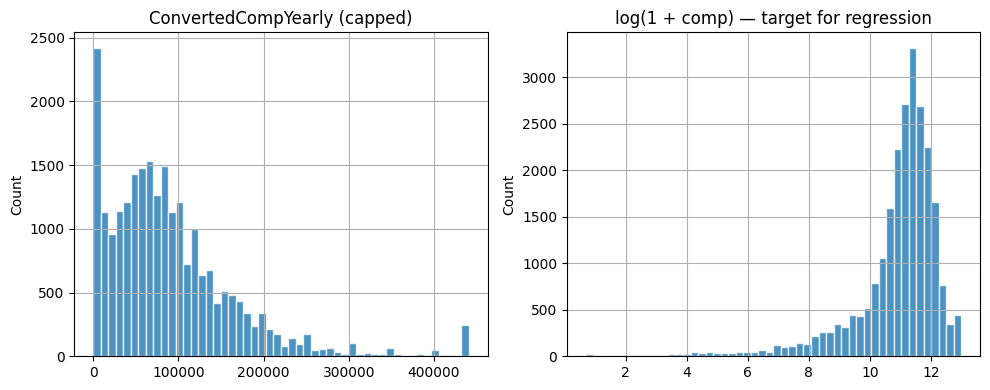

Country_top
United States of America                                150000.0
Switzerland                                             142592.0
Australia                                                97514.0
United Kingdom of Great Britain and Northern Ireland     94618.0
Canada                                                   87550.0
Netherlands                                              81210.0
Germany                                                  81210.0
Sweden                                                   70440.0
France                                                   63228.0
Spain                                                    62648.0
Name: ConvertedCompYearly, dtype: float64

In [144]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
work.loc[mask, TARGET].hist(ax=axes[0], bins=50, edgecolor="white", alpha=0.8)
axes[0].set_title("ConvertedCompYearly (capped)")
axes[0].set_ylabel("Count")
work.loc[mask, "log_comp"].hist(ax=axes[1], bins=50, edgecolor="white", alpha=0.8)
axes[1].set_title("log(1 + comp) — target for regression")
axes[1].set_ylabel("Count")
plt.tight_layout()
plt.show()
# Median compensation by top country (sample)
work.loc[mask].groupby("Country_top")[TARGET].median().sort_values(ascending=False).head(10)

---

## 3. Train/test split and baselines

Single random split (reproducible with `RANDOM_STATE`). Median baseline: predict train median for everyone on test. Linear Regression baseline: fit on `X`, target `y_log`. Metrics: R², RMSE, MAE (on test).

In [145]:
# Train/test split (same split for all models)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_log, test_size=0.2, random_state=RANDOM_STATE
)
# Align y_level for test set (for RMSE/MAE in USD later if needed)
_, _, _, y_level_test = train_test_split(X, y_level, test_size=0.2, random_state=RANDOM_STATE)

# Median baseline: predict train median for everyone
median_log = y_train.median()
pred_median = np.full_like(y_test, median_log)
results = []
results.append({
    "Model": "Median (baseline)",
    "R²": r2_score(y_test, pred_median),
    "RMSE (log)": np.sqrt(mean_squared_error(y_test, pred_median)),
    "MAE (log)": mean_absolute_error(y_test, pred_median),
})

# Linear Regression baseline
lr = LinearRegression().fit(X_train, y_train)
pred_lr = lr.predict(X_test)
results.append({
    "Model": "Linear Regression",
    "R²": r2_score(y_test, pred_lr),
    "RMSE (log)": np.sqrt(mean_squared_error(y_test, pred_lr)),
    "MAE (log)": mean_absolute_error(y_test, pred_lr),
})

pd.DataFrame(results)

,Model,R²,RMSE (log),MAE (log)
0,Median (baseline),-0.06138,1.607860,0.951810
1,Linear Regression,0.29805,1.307573,0.769029


### What affects salary most (from the data)

Linear Regression coefficients show which features move log-salary up or down. Positive = higher salary with that feature; negative = lower. Sorted by impact (absolute coefficient). Country, org size, and language/tech stack all feed into these.

Top 20 drivers of salary (by |coefficient|):


,feature,coefficient,abs_coef
0,Country_Ukraine,-1.283713,1.283713
1,Country_India,-0.995004,0.995004
2,Country_Switzerland,0.869135,0.869135
3,Country_Brazil,-0.793620,0.793620
4,Country_United States of America,0.758863,0.758863
5,DevType_Academic researcher,-0.589979,0.589979
6,Country_Other,-0.500519,0.500519
7,Country_Australia,0.436922,0.436922
8,Country_United Kingdom of Great Britain and No...,0.424966,0.424966
9,Country_Canada,0.399593,0.399593


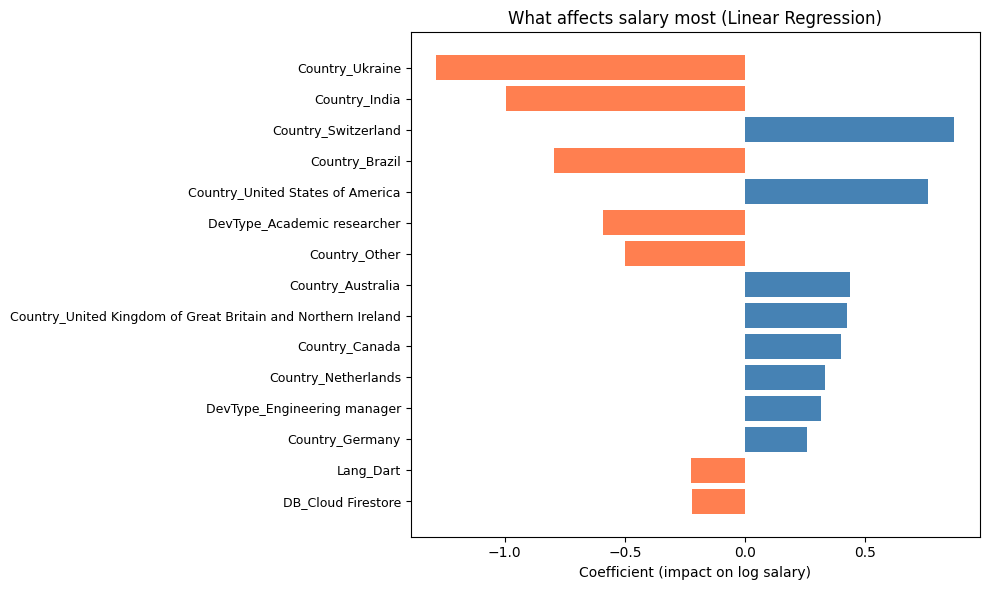

In [146]:
# Feature impact from Linear Regression (coefficients on log-salary)
coef_df = pd.DataFrame({"feature": X_train.columns, "coefficient": lr.coef_})
coef_df["abs_coef"] = coef_df["coefficient"].abs()
coef_df = coef_df.sort_values("abs_coef", ascending=False).reset_index(drop=True)
print("Top 20 drivers of salary (by |coefficient|):")
display(coef_df.head(20))
# Bar chart of top 15
top15 = coef_df.head(15)
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(len(top15)), top15["coefficient"], color=np.where(top15["coefficient"] > 0, "steelblue", "coral"))
ax.set_yticks(range(len(top15)))
ax.set_yticklabels(top15["feature"], fontsize=9)
ax.set_xlabel("Coefficient (impact on log salary)")
ax.set_title("What affects salary most (Linear Regression)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

---

## 4. Improved models

Train at least one improved model (e.g. Random Forest, XGBoost). Optionally tune with GridSearchCV/RandomizedSearchCV. Evaluate on the same test set and add to the results table.

### Pushing toward R² ≥ 0.55: XGBoost and tuning

Try **XGBoost** (often better than RF on tabular data). Then **tune** a few hyperparameters with `RandomizedSearchCV` to squeeze out more R². If you still land below 0.55, report the best you got and discuss why (noisy target, geography skew, etc.)—a clear process still counts.

In [147]:
# XGBoost (install first if needed: %pip install xgboost --quiet)
try:
    from xgboost import XGBRegressor
except ImportError:
    import subprocess; subprocess.run(["pip", "install", "xgboost", "-q"], check=True)
    from xgboost import XGBRegressor

xgb_model = XGBRegressor(n_estimators=200, max_depth=8, learning_rate=0.1, random_state=RANDOM_STATE, n_jobs=-1)
xgb_model.fit(X_train, y_train)
pred_xgb = xgb_model.predict(X_test)
results.append({"Model": "XGBoost", "R²": r2_score(y_test, pred_xgb), "RMSE (log)": np.sqrt(mean_squared_error(y_test, pred_xgb)), "MAE (log)": mean_absolute_error(y_test, pred_xgb)})
pd.DataFrame(results)

,Model,R²,RMSE (log),MAE (log)
0,Median (baseline),-0.061380,1.607860,0.951810
1,Linear Regression,0.298050,1.307573,0.769029
2,XGBoost,0.347885,1.260303,0.698067


In [148]:
# Optional: tune XGBoost to try to reach R² ≥ 0.55 (takes ~1–3 min)
param_grid = {"n_estimators": [150, 250], "max_depth": [6, 10, 14], "learning_rate": [0.05, 0.1], "subsample": [0.8, 1.0]}
search = RandomizedSearchCV(XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1), param_grid, n_iter=8, cv=3, scoring="r2", random_state=RANDOM_STATE, n_jobs=-1)
search.fit(X_train, y_train)
pred_tuned = search.predict(X_test)
results.append({"Model": "XGBoost (tuned)", "R²": r2_score(y_test, pred_tuned), "RMSE (log)": np.sqrt(mean_squared_error(y_test, pred_tuned)), "MAE (log)": mean_absolute_error(y_test, pred_tuned)})
print("Best params:", search.best_params_)
pd.DataFrame(results)

Best params: {'subsample': 0.8, 'n_estimators': 150, 'max_depth': 6, 'learning_rate': 0.05}


,Model,R²,RMSE (log),MAE (log)
0,Median (baseline),-0.061380,1.607860,0.951810
1,Linear Regression,0.298050,1.307573,0.769029
2,XGBoost,0.347885,1.260303,0.698067
3,XGBoost (tuned),0.377636,1.231218,0.669426


In [149]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=RANDOM_STATE)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)
results.append({"Model": "Random Forest", "R²": r2_score(y_test, pred_rf), "RMSE (log)": np.sqrt(mean_squared_error(y_test, pred_rf)), "MAE (log)": mean_absolute_error(y_test, pred_rf)})
pd.DataFrame(results)

,Model,R²,RMSE (log),MAE (log)
0,Median (baseline),-0.061380,1.607860,0.951810
1,Linear Regression,0.298050,1.307573,0.769029
2,XGBoost,0.347885,1.260303,0.698067
3,XGBoost (tuned),0.377636,1.231218,0.669426
4,Random Forest,0.331817,1.275735,0.716791


---

## 5. Evaluation and conclusions

Compare all models in one table. Use SHAP on the best model for top-10 feature interpretation. Summarize: which model won, why, and what you recommend.

In [150]:
# Final comparison table
# pd.DataFrame(results)
# SHAP (after: pip install shap): e.g. shap.TreeExplainer(best_model, X_test).shap_values(X_test)
# Plot top 10 features and write 1–2 sentences per major driver.